### Implementing simple Chatbot Using LangGraph

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

## Import LLM models using API
import os
from dotenv import load_dotenv
load_dotenv()

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

## Create the class
class State(TypedDict):

    ## Returns in key value pairs since its in TypedDict
    ## Annotated and add_messages => appends the conversation, not overwrites
    ## In form of a list, and add_messages function hnelps
    messages:Annotated[list, add_messages]

In [2]:
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

## Required paid tokens
## llm = ChatOpenAI(model="gpt-4o")
## llm.invoke("Hello")

## Open source LLM models
llm_groq = ChatGroq(model = "openai/gpt-oss-120b")
llm_groq.invoke("Hey I am Dhruv and I like to play cricket")

AIMessage(content='Hey Dhruv! Great to meet you. 🎉\n\nCricket’s such an exciting sport—whether you’re into batting, bowling, fielding, or just cheering from the stands, there’s always something thrilling happening. Do you have a favorite team or player? Or maybe you like to play a particular format (Test, ODI, T20) yourself? I’d love to hear more about your cricket adventures!', additional_kwargs={'reasoning_content': 'The user says: "Hey I am Dhruv and i like to play cricket". Likely they are just greeting. The assistant should respond politely, maybe ask about cricket preferences, etc. There\'s no disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 144, 'prompt_tokens': 83, 'total_tokens': 227, 'completion_time': 0.300581462, 'completion_tokens_details': {'reasoning_tokens': 50}, 'prompt_time': 0.003227423, 'prompt_tokens_details': None, 'queue_time': 0.018032574, 'total_time': 0.303808885}, 'model_name': 'openai/gpt-oss-120b', 'system_

### Start creating nodes

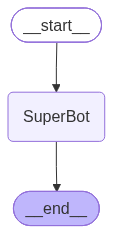

In [3]:
## Return in form of dictionary
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

graph = StateGraph(State)

## Nodes
graph.add_node("SuperBot",superbot)

## Edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder = graph.compile()

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [4]:
## Invocation
graph_builder.invoke({'messages': "Hi, My name is Dhruv And I like to play cricket"})

{'messages': [HumanMessage(content='Hi, My name is Dhruv And I like to play cricket', additional_kwargs={}, response_metadata={}, id='814aa842-ada5-4947-bf88-824e277b97c5'),
  AIMessage(content='Hi Dhruv! 👋 Great to meet you. Cricket is such an exciting sport—whether you’re batting, bowling, or just cheering from the stands.  \n\nDo you have a favorite format (Test, ODI, T20) or a favorite team/player you root for? I’d love to hear more about what you enjoy most about the game!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Dhruv And I like to play cricket". Probably wants a response. We should greet, ask about cricket, maybe ask about favorite player, etc. No disallowed content. Just respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 131, 'prompt_tokens': 85, 'total_tokens': 216, 'completion_time': 0.279603024, 'completion_tokens_details': {'reasoning_tokens': 50}, 'prompt_time': 0.003441289, 'prompt_tokens_details': None, 'queue_tim

In [6]:
## Invocation
graph_builder.invoke({'messages': "Yes! I like test and ODI cricket more, and my favourite team is India!"})

{'messages': [HumanMessage(content='Yes! I like test and ODI cricket more, and my favourite team is India!', additional_kwargs={}, response_metadata={}, id='0402b58b-f6dd-475a-a0ba-aae05552d19f'),
  AIMessage(content='That’s awesome! India has a rich history in both Test and ODI cricket, so you’ve got plenty to cheer about.\n\n**Test cricket highlights**\n- **Recent success:** India’s overseas win in England (2021) and the historic series win in New\u202fZealand (2023) showed the team’s resilience in the longest format.\n- **Key players:** Virat Kohli’s masterclass in chasing, Ajinkya Rahane’s calm leadership, and the spin duo of Ravichandran Ashwin & Ravindra Jadeja have been pivotal.\n- **What to watch:** The upcoming series against Australia – a classic Test rivalry that always produces thrilling moments.\n\n**ODI cricket highlights**\n- **World Cup glory:** The 2011 triumph on home soil is still fresh in fans’ hearts, and the 2023 run‑up to the next World Cup promises more drama.\n

#### Streaming The responses

In [7]:
## graph_builder.stream({"messages": "Hello My name is Dhruv"}) is an object
for event in graph_builder.stream({"messages": "Hello My name is Dhruv"}, stream_mode= 'values'):
    print(event)

{'messages': [HumanMessage(content='Hello My name is Dhruv', additional_kwargs={}, response_metadata={}, id='7346316d-1efb-4c16-b175-628cd4d9f0f5')]}
{'messages': [HumanMessage(content='Hello My name is Dhruv', additional_kwargs={}, response_metadata={}, id='7346316d-1efb-4c16-b175-628cd4d9f0f5'), AIMessage(content='Hello Dhruv! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hello My name is Dhruv". We should respond politely, perhaps ask how can help. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 78, 'total_tokens': 132, 'completion_time': 0.114814824, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.002893257, 'prompt_tokens_details': None, 'queue_time': 0.149420844, 'total_time': 0.117708081}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_dc4ca88fa4', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provide